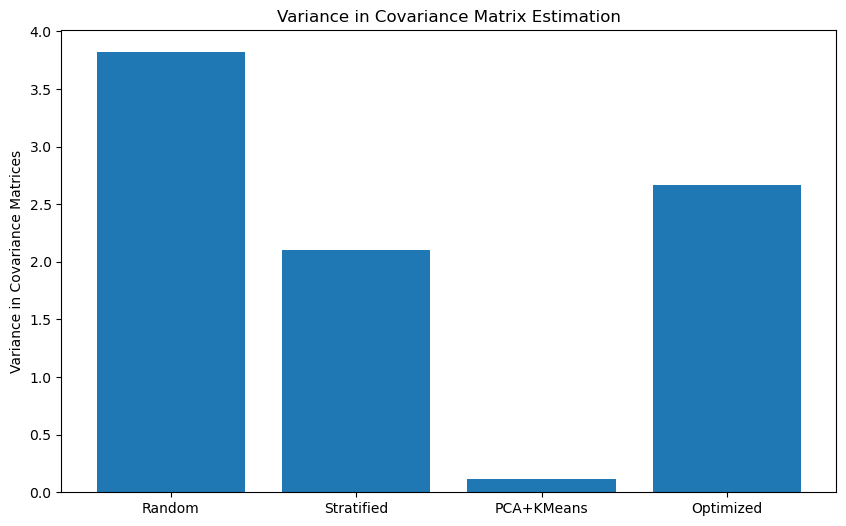

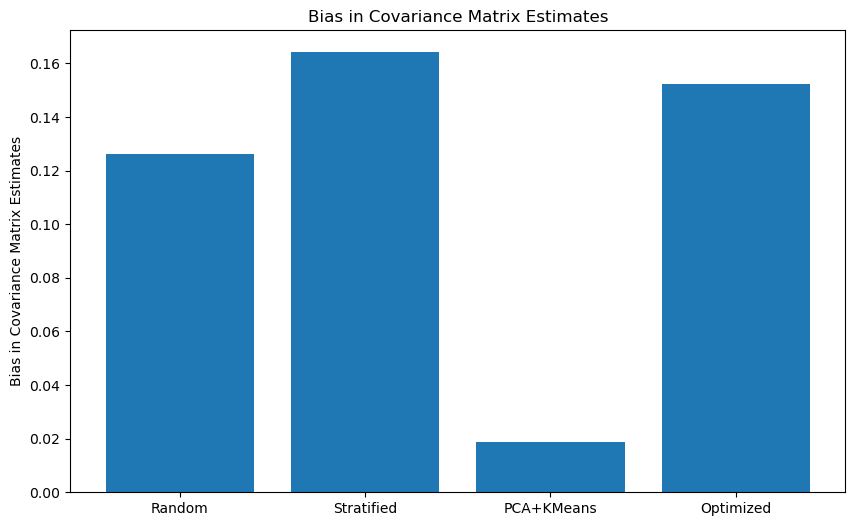

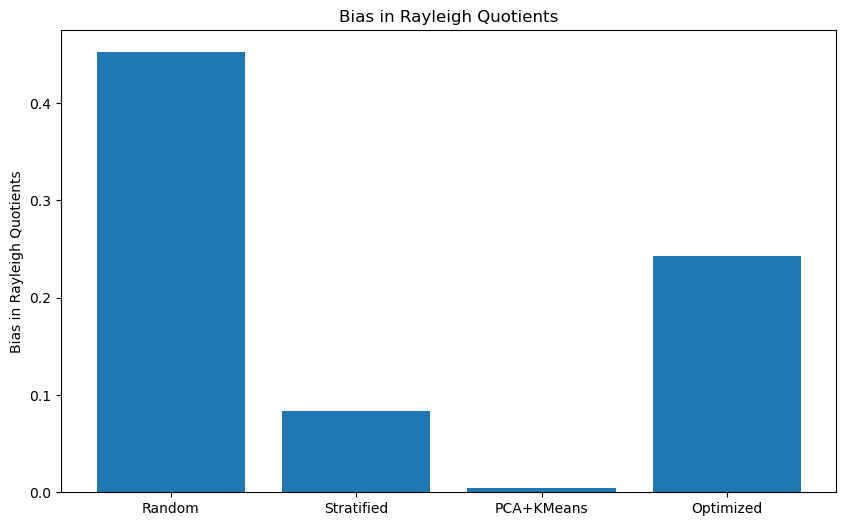

NameError: name 'rq_rq_mean_optimized' is not defined

<Figure size 1000x600 with 0 Axes>

In [30]:
# Necessary imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.optimize import minimize
from sklearn.datasets import make_classification

# Generate synthetic dataset
X, y = make_classification(n_samples=1000, n_features=10, n_informative=5, n_classes=2, random_state=42)
w = np.random.randn(10)  # Random weight vector for Rayleigh Quotient calculation
batch_size = 50
num_batches = 10

# Function to compute the covariance matrix for a given batch
def compute_covariance_matrix(X_batch):
    return np.cov(X_batch, rowvar=False)

# Function to compute the Rayleigh Quotient for a given weight vector and covariance matrix
def compute_rayleigh_quotient(w, cov_matrix):
    return (w.T @ cov_matrix @ w) / (w.T @ w)

# Function to compute the bias for covariance matrices and Rayleigh Quotients
def compute_bias(cov_matrices, rq_values, cov_whole, rq_whole):
    # Mean covariance matrix across batches
    mean_cov = np.mean(cov_matrices, axis=0)
    bias_cov = mean_cov - cov_whole

    # Mean RQ across batches
    mean_rq = np.mean(rq_values)
    bias_rq = mean_rq - rq_whole

    return np.mean(np.abs(bias_cov)), np.abs(bias_rq)  # Return the magnitude of bias for plotting

# Bayesian estimation of the overall RQ using batch RQs and their variances
def bayesian_estimation_rq(rq_values, variances):
    # Compute the weights as 1 / variance (smaller variance => higher weight)
    weights = 1 / np.array(variances)
    
    # Compute the Bayesian estimate of the RQ as the weighted average
    bayesian_rq = np.sum(weights * rq_values) / np.sum(weights)
    
    # Return the Bayesian estimate and the variance of the estimate
    bayesian_variance = 1 / np.sum(weights)
    
    return bayesian_rq, bayesian_variance

# Function to compute the variance of covariance matrices based on the Frobenius norm
def compute_covariance_variance(cov_matrices):
    # Compute the Frobenius norm of each covariance matrix
    frobenius_norms = [np.linalg.norm(cov_matrix, 'fro') for cov_matrix in cov_matrices]
    
    # Compute and return the variance of the Frobenius norms
    return np.var(frobenius_norms)

# Function to compute the variance and mean for bias and variance with errorbars over nodes
def compute_bias_variance_over_nodes(cov_matrices, rq_values, cov_whole, rq_whole):
    # Bias and variance for covariance matrices
    biases_cov = [np.mean(np.abs(np.mean(batch_cov, axis=0) - cov_whole)) for batch_cov in cov_matrices]
    variances_cov = [np.var(batch_cov) for batch_cov in cov_matrices]

    # Bias and variance for RQ
    biases_rq = [np.abs(np.mean(rq_values[i]) - rq_whole) for i in range(len(rq_values))]
    variances_rq = [np.var(rq_values[i]) for i in range(len(rq_values))]

    # Average and standard deviation of biases and variances
    avg_bias_cov, std_bias_cov = np.mean(biases_cov), np.std(biases_cov)
    avg_var_cov, std_var_cov = np.mean(variances_cov), np.std(variances_cov)

    avg_bias_rq, std_bias_rq = np.mean(biases_rq), np.std(biases_rq)
    avg_var_rq, std_var_rq = np.mean(variances_rq), np.std(variances_rq)

    return {
        'avg_bias_cov': avg_bias_cov, 'std_bias_cov': std_bias_cov,
        'avg_var_cov': avg_var_cov, 'std_var_cov': std_var_cov,
        'avg_bias_rq': avg_bias_rq, 'std_bias_rq': std_bias_rq,
        'avg_var_rq': avg_var_rq, 'std_var_rq': std_var_rq
    }

# Random sampling function for batches
def random_sampling(X, batch_size, num_batches):
    cov_matrices = []
    for _ in range(num_batches):
        indices = np.random.choice(len(X), batch_size, replace=False)
        X_batch = X[indices]
        cov_matrices.append(compute_covariance_matrix(X_batch))
    return cov_matrices

# Stratified sampling based on clustering
def stratified_sampling(X, cluster_labels, batch_size, num_batches):
    cov_matrices = []
    unique_labels = np.unique(cluster_labels)
    samples_per_batch = batch_size // len(unique_labels)

    for _ in range(num_batches):
        batch = []
        for label in unique_labels:
            X_cluster = X[cluster_labels == label]
            np.random.shuffle(X_cluster)
            batch.append(X_cluster[:samples_per_batch])
        cov_matrices.append(compute_covariance_matrix(np.concatenate(batch, axis=0)))
    return cov_matrices

# Function to compute RQ variances for batches
def compute_rq_variances(cov_matrices, w):
    rq_values = [compute_rayleigh_quotient(w, cov) for cov in cov_matrices]
    
    # Estimate the variance of RQ for each batch (this could be refined based on batch size)
    variances = [np.var(cov_matrix) for cov_matrix in cov_matrices]
    
    return rq_values, variances

# PCA + KMeans clustering-based stratification
def pca_kmeans_stratification(X, num_clusters, n_components=5):
    # Step 1: Apply PCA to reduce dimensionality
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)

    # Step 2: Apply KMeans clustering in PCA space
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(X_pca)

    return cluster_labels

# Optimization-based partitioning to minimize covariance variance
def partition_covariance_minimization(X, num_batches):
    batch_size = len(X) // num_batches

    def objective(partition):
        partitioned_data = [X[partition == i] for i in range(num_batches)]
        cov_matrices = [compute_covariance_matrix(batch) for batch in partitioned_data]
        
        # Use Frobenius norm as a scalar measure of each covariance matrix
        frobenius_norms = [np.linalg.norm(cov_matrix, 'fro') for cov_matrix in cov_matrices]
        
        # Compute variance of the Frobenius norms
        return np.var(frobenius_norms)

    # Initial random partition
    initial_partition = np.random.randint(0, num_batches, size=len(X))

    # Optimize partitioning to minimize covariance variance
    result = minimize(objective, initial_partition, method='Powell')
    optimized_partition = np.round(result.x).astype(int)
    return optimized_partition

# Optimization based on Mean RQ
def partition_rq_mean_minimization(X, num_batches, w):
    batch_size = len(X) // num_batches

    def objective(partition):
        partitioned_data = [X[partition == i] for i in range(num_batches)]
        rq_values = [compute_rayleigh_quotient(w, compute_covariance_matrix(batch)) for batch in partitioned_data]
        mean_rq = np.mean(rq_values)
        rq_whole = compute_rayleigh_quotient(w, compute_covariance_matrix(X))
        return np.abs(mean_rq - rq_whole)

    # Initial random partition
    initial_partition = np.random.randint(0, num_batches, size=len(X))

    # Optimize partitioning to minimize RQ mean difference
    result = minimize(objective, initial_partition, method='Powell')
    optimized_partition = np.round(result.x).astype(int)
    return optimized_partition

# Function to compute the covariance matrices and RQ, along with variance and bias
def compute_covariances_rq_bias_with_pca_kmeans(X, batch_size, num_batches, w):
    # Full data covariance matrix and RQ
    cov_whole = compute_covariance_matrix(X)
    rq_whole = compute_rayleigh_quotient(w, cov_whole)

    # Random Sampling
    cov_matrices_random = random_sampling(X, batch_size, num_batches)
    variance_random = compute_covariance_variance(cov_matrices_random)
    rq_random = [compute_rayleigh_quotient(w, cov) for cov in cov_matrices_random]
    bias_cov_random, bias_rq_random = compute_bias(cov_matrices_random, rq_random, cov_whole, rq_whole)

    # Covariance-Based Stratified Sampling
    cluster_labels = pca_kmeans_stratification(X, num_batches)
    cov_matrices_stratified = stratified_sampling(X, cluster_labels, batch_size, num_batches)
    variance_stratified = compute_covariance_variance(cov_matrices_stratified)
    rq_stratified = [compute_rayleigh_quotient(w, cov) for cov in cov_matrices_stratified]
    bias_cov_stratified, bias_rq_stratified = compute_bias(cov_matrices_stratified, rq_stratified, cov_whole, rq_whole)

    # Optimization-Based Partitioning (Variance Minimization)
    optimized_partition = partition_covariance_minimization(X, num_batches)
    cov_matrices_optimized = [compute_covariance_matrix(X[optimized_partition == i]) for i in range(num_batches)]
    variance_optimized = compute_covariance_variance(cov_matrices_optimized)
    rq_optimized = [compute_rayleigh_quotient(w, cov) for cov in cov_matrices_optimized]
    bias_cov_optimized, bias_rq_optimized = compute_bias(cov_matrices_optimized, rq_optimized, cov_whole, rq_whole)

    # PCA + KMeans clustering stratification
    cluster_labels_pca_kmeans = pca_kmeans_stratification(X, num_batches)
    cov_matrices_pca_kmeans = stratified_sampling(X, cluster_labels_pca_kmeans, batch_size, num_batches)
    variance_pca_kmeans = compute_covariance_variance(cov_matrices_pca_kmeans)
    rq_pca_kmeans = [compute_rayleigh_quotient(w, cov) for cov in cov_matrices_pca_kmeans]
    bias_cov_pca_kmeans, bias_rq_pca_kmeans = compute_bias(cov_matrices_pca_kmeans, rq_pca_kmeans, cov_whole, rq_whole)

    # New Optimization Based on Mean RQ
    optimized_partition_rq_mean = partition_rq_mean_minimization(X, num_batches, w)
    cov_matrices_rq_mean_optimized = [compute_covariance_matrix(X[optimized_partition_rq_mean == i]) for i in range(num_batches)]
    variance_rq_mean_optimized = compute_covariance_variance(cov_matrices_rq_mean_optimized)
    rq_rq_mean_optimized = [compute_rayleigh_quotient(w, cov) for cov in cov_matrices_rq_mean_optimized]
    bias_cov_rq_mean_optimized, bias_rq_rq_mean_optimized = compute_bias(cov_matrices_rq_mean_optimized, rq_rq_mean_optimized, cov_whole, rq_whole)

    return {
        'variance_random': variance_random,
        'variance_stratified': variance_stratified,
        'variance_optimized': variance_optimized,
        'variance_pca_kmeans': variance_pca_kmeans,
        'variance_rq_mean_optimized': variance_rq_mean_optimized,  # Added
        'rq_random': rq_random,
        'rq_stratified': rq_stratified,
        'rq_optimized': rq_optimized,
        'rq_pca_kmeans': rq_pca_kmeans,
        'rq_rq_mean_optimized': rq_rq_mean_optimized,  # Added
        'bias_cov_random': bias_cov_random,
        'bias_cov_stratified': bias_cov_stratified,
        'bias_cov_optimized': bias_cov_optimized,
        'bias_cov_pca_kmeans': bias_cov_pca_kmeans,
        'bias_cov_rq_mean_optimized': bias_cov_rq_mean_optimized,  # Added
        'bias_rq_random': bias_rq_random,
        'bias_rq_stratified': bias_rq_stratified,
        'bias_rq_optimized': bias_rq_optimized,
        'bias_rq_pca_kmeans': bias_rq_pca_kmeans,
        'bias_rq_rq_mean_optimized': bias_rq_rq_mean_optimized  # Added
    }

# Updated visualization function to include both optimizations
def plot_results_with_pca_kmeans_and_optimizations(variances, biases_cov, biases_rq, rq_random, rq_stratified, rq_pca_kmeans, rq_optimized):
    # Plot variances in covariance matrix estimates
    plt.figure(figsize=(10, 6))
    plt.bar(['Random', 'Stratified', 'PCA+KMeans', 'Optimized'], variances)
    plt.ylabel('Variance in Covariance Matrices')
    plt.title('Variance in Covariance Matrix Estimation')
    plt.show()

    # Plot bias in covariance matrix estimates
    plt.figure(figsize=(10, 6))
    plt.bar(['Random', 'Stratified', 'PCA+KMeans', 'Optimized'], biases_cov)
    plt.ylabel('Bias in Covariance Matrix Estimates')
    plt.title('Bias in Covariance Matrix Estimates')
    plt.show()

    # Plot bias in Rayleigh Quotients
    plt.figure(figsize=(10, 6))
    plt.bar(['Random', 'Stratified', 'PCA+KMeans', 'Optimized'], biases_rq)
    plt.ylabel('Bias in Rayleigh Quotients')
    plt.title('Bias in Rayleigh Quotients')
    plt.show()

    # # Plot Rayleigh Quotients (box plot to see distribution)
    # plt.figure(figsize=(10, 6))
    # plt.boxplot([rq_random, rq_stratified, rq_optimized, rq_pca_kmeans], labels=['Random', 'Stratified', 'PCA+KMeans', 'Optimized'])
    # plt.ylabel('Rayleigh Quotients')
    # plt.title('Rayleigh Quotients Across Methods')
    # plt.show()

# Compute results including PCA + KMeans clustering and both optimizations
results = compute_covariances_rq_bias_with_pca_kmeans(X, batch_size, num_batches, w)

# Plot the results including PCA + KMeans clustering and both optimizations
plot_results_with_pca_kmeans_and_optimizations(
    [results['variance_random'], results['variance_stratified'], results['variance_optimized'], results['variance_pca_kmeans']],
    [results['bias_cov_random'], results['bias_cov_stratified'], results['bias_cov_optimized'], results['bias_cov_pca_kmeans']],
    [results['bias_rq_random'], results['bias_rq_stratified'], results['bias_rq_optimized'], results['bias_rq_pca_kmeans']],
    results['rq_random'], results['rq_stratified'], results['rq_optimized'], results['rq_pca_kmeans']
)


# Function to compute the covariance matrices and RQ, along with variance and bias
def compute_covariances_rq_bias_with_pca_kmeans_bayesian(X, batch_size, num_batches, w):
    # Full data covariance matrix and RQ
    cov_whole = compute_covariance_matrix(X)
    rq_whole = compute_rayleigh_quotient(w, cov_whole)

    # Random Sampling
    cov_matrices_random = random_sampling(X, batch_size, num_batches)
    variance_random = compute_covariance_variance(cov_matrices_random)
    rq_random, rq_variances_random = compute_rq_variances(cov_matrices_random, w)
    bias_cov_random, bias_rq_random = compute_bias(cov_matrices_random, rq_random, cov_whole, rq_whole)

    # Covariance-Based Stratified Sampling
    cluster_labels = pca_kmeans_stratification(X, num_batches)
    cov_matrices_stratified = stratified_sampling(X, cluster_labels, batch_size, num_batches)
    variance_stratified = compute_covariance_variance(cov_matrices_stratified)
    rq_stratified, rq_variances_stratified = compute_rq_variances(cov_matrices_stratified, w)
    bias_cov_stratified, bias_rq_stratified = compute_bias(cov_matrices_stratified, rq_stratified, cov_whole, rq_whole)

    # Bayesian Estimation for RQ
    bayesian_rq_random, bayesian_variance_random = bayesian_estimation_rq(rq_random, rq_variances_random)
    bayesian_rq_stratified, bayesian_variance_stratified = bayesian_estimation_rq(rq_stratified, rq_variances_stratified)

    # Optimization-Based Partitioning (Variance Minimization)
    optimized_partition = partition_covariance_minimization(X, num_batches)
    cov_matrices_optimized = [compute_covariance_matrix(X[optimized_partition == i]) for i in range(num_batches)]
    variance_optimized = compute_covariance_variance(cov_matrices_optimized)
    rq_optimized, rq_variances_optimized = compute_rq_variances(cov_matrices_optimized, w)
    bias_cov_optimized, bias_rq_optimized = compute_bias(cov_matrices_optimized, rq_optimized, cov_whole, rq_whole)

    # PCA + KMeans clustering stratification
    cluster_labels_pca_kmeans = pca_kmeans_stratification(X, num_batches)
    cov_matrices_pca_kmeans = stratified_sampling(X, cluster_labels_pca_kmeans, batch_size, num_batches)
    variance_pca_kmeans = compute_covariance_variance(cov_matrices_pca_kmeans)
    rq_pca_kmeans, rq_variances_pca_kmeans = compute_rq_variances(cov_matrices_pca_kmeans, w)
    bias_cov_pca_kmeans, bias_rq_pca_kmeans = compute_bias(cov_matrices_pca_kmeans, rq_pca_kmeans, cov_whole, rq_whole)

    # New Optimization Based on Mean RQ
    optimized_partition_rq_mean = partition_rq_mean_minimization(X, num_batches, w)
    cov_matrices_rq_mean_optimized = [compute_covariance_matrix(X[optimized_partition_rq_mean == i]) for i in range(num_batches)]
    variance_rq_mean_optimized = compute_covariance_variance(cov_matrices_rq_mean_optimized)
    rq_rq_mean_optimized, rq_variances_rq_mean_optimized = compute_rq_variances(cov_matrices_rq_mean_optimized, w)
    bias_cov_rq_mean_optimized, bias_rq_rq_mean_optimized = compute_bias(cov_matrices_rq_mean_optimized, rq_rq_mean_optimized, cov_whole, rq_whole)

    return {
        'variance_random': variance_random,
        'variance_stratified': variance_stratified,
        'variance_optimized': variance_optimized,
        'variance_pca_kmeans': variance_pca_kmeans,
        'variance_rq_mean_optimized': variance_rq_mean_optimized,  # Added
        'rq_random': rq_random,
        'rq_stratified': rq_stratified,
        'rq_optimized': rq_optimized,
        'rq_pca_kmeans': rq_pca_kmeans,
        'rq_rq_mean_optimized': rq_rq_mean_optimized,  # Added
        'bias_cov_random': bias_cov_random,
        'bias_cov_stratified': bias_cov_stratified,
        'bias_cov_optimized': bias_cov_optimized,
        'bias_cov_pca_kmeans': bias_cov_pca_kmeans,
        'bias_cov_rq_mean_optimized': bias_cov_rq_mean_optimized,  # Added
        'bias_rq_random': bias_rq_random,
        'bias_rq_stratified': bias_rq_stratified,
        'bias_rq_optimized': bias_rq_optimized,
        'bias_rq_pca_kmeans': bias_rq_pca_kmeans,
        'bias_rq_rq_mean_optimized': bias_rq_rq_mean_optimized,  # Added
        'bayesian_rq_random': bayesian_rq_random,  # Bayesian estimate
        'bayesian_variance_random': bayesian_variance_random,  # Variance of Bayesian estimate
        'bayesian_rq_stratified': bayesian_rq_stratified,  # Bayesian estimate for stratified
        'bayesian_variance_stratified': bayesian_variance_stratified  # Variance of Bayesian estimate
    }

# Updated visualization function to include Bayesian estimates
def plot_results_with_bayesian_approach(variances, biases_cov, biases_rq, rq_random, rq_stratified, rq_pca_kmeans, rq_optimized, bayesian_rq_random, bayesian_rq_stratified):
    # Plot variances in covariance matrix estimates
    plt.figure(figsize=(10, 6))
    plt.bar(['Random', 'Stratified', 'PCA+KMeans', 'Optimized'], variances)
    plt.ylabel('Variance in Covariance Matrices')
    plt.title('Variance in Covariance Matrix Estimation')
    plt.show()

    # Plot bias in covariance matrix estimates
    plt.figure(figsize=(10, 6))
    plt.bar(['Random', 'Stratified', 'PCA+KMeans', 'Optimized'], biases_cov)
    plt.ylabel('Bias in Covariance Matrix Estimates')
    plt.title('Bias in Covariance Matrix Estimates')
    plt.show()

    # Plot bias in Rayleigh Quotients
    plt.figure(figsize=(10, 6))
    plt.bar(['Random', 'Stratified', 'PCA+KMeans', 'Optimized'], biases_rq)
    plt.ylabel('Bias in Rayleigh Quotients')
    plt.title('Bias in Rayleigh Quotients')
    plt.show()

    # Plot Rayleigh Quotients (box plot to see distribution)
    plt.figure(figsize=(10, 6))
    plt.boxplot([rq_random, rq_stratified, rq_optimized, rq_pca_kmeans], labels=['Random', 'Stratified', 'PCA+KMeans', 'Optimized'])
    plt.ylabel('Rayleigh Quotients')
    plt.title('Rayleigh Quotients Across Methods')
    plt.show()

    # Display Bayesian estimates for Random and Stratified methods
    print(f"Bayesian RQ (Random Sampling): {bayesian_rq_random}")
    print(f"Bayesian RQ (Stratified Sampling): {bayesian_rq_stratified}")

# Compute results including Bayesian estimation
results = compute_covariances_rq_bias_with_pca_kmeans_bayesian(X, batch_size, num_batches, w)

# Plot the results including Bayesian estimation
plot_results_with_bayesian_approach(
    [results['variance_random'], results['variance_stratified'], results['variance_optimized'], results['variance_pca_kmeans']],
    [results['bias_cov_random'], results['bias_cov_stratified'], results['bias_cov_optimized'], results['bias_cov_pca_kmeans']],
    [results['bias_rq_random'], results['bias_rq_stratified'], results['bias_rq_optimized'], results['bias_rq_pca_kmeans']],
    results['rq_random'], results['rq_stratified'], results['rq_pca_kmeans'], results['rq_optimized'],
    results['bayesian_rq_random'], results['bayesian_rq_stratified']
)

In [ ]:
# Plot the results including PCA + KMeans clustering and both optimizations
plot_results_with_pca_kmeans_and_optimizations(
    [results['variance_random'], results['variance_stratified'], results['variance_pca_kmeans'], results['variance_optimized']],
    [results['bias_cov_random'], results['bias_cov_stratified'], results['bias_cov_pca_kmeans'], results['bias_cov_optimized']],
    [results['bias_rq_random'], results['bias_rq_stratified'], results['bias_rq_pca_kmeans'], results['bias_rq_optimized']],
    results['rq_random'], results['rq_stratified'], results['rq_pca_kmeans'], results['rq_optimized']
)

KeyError: 'variance_random'


Random Sampling Debug:
Covariance Matrix Differences (Frobenius Norm):
Batch 0 vs Batch 1: Frobenius Norm of Covariance Difference = 6.496258746122406
Batch 1 vs Batch 2: Frobenius Norm of Covariance Difference = 5.549507851780137
Batch 2 vs Batch 3: Frobenius Norm of Covariance Difference = 3.988722214698494
Batch 3 vs Batch 4: Frobenius Norm of Covariance Difference = 5.077331700060118
Batch 4 vs Batch 5: Frobenius Norm of Covariance Difference = 5.486655372944425
Batch 5 vs Batch 6: Frobenius Norm of Covariance Difference = 6.382017192329525
Batch 6 vs Batch 7: Frobenius Norm of Covariance Difference = 5.040453523688142
Batch 7 vs Batch 8: Frobenius Norm of Covariance Difference = 4.603004620221608
Batch 8 vs Batch 9: Frobenius Norm of Covariance Difference = 5.016593814500848

Rayleigh Quotients for each batch:
Batch 0: RQ = 2.071753867849847
Batch 1: RQ = 4.046068684896381
Batch 2: RQ = 4.9060835050737115
Batch 3: RQ = 3.1902773472483688
Batch 4: RQ = 5.708720677316844
Batch 5: R

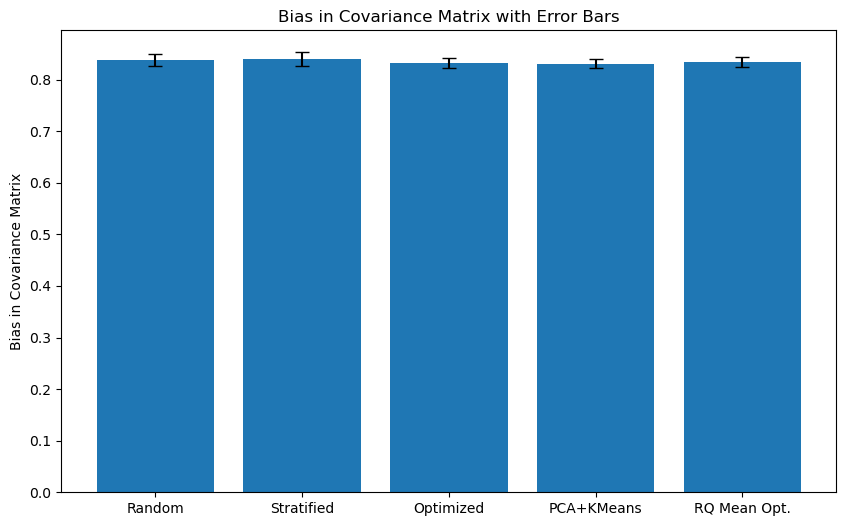

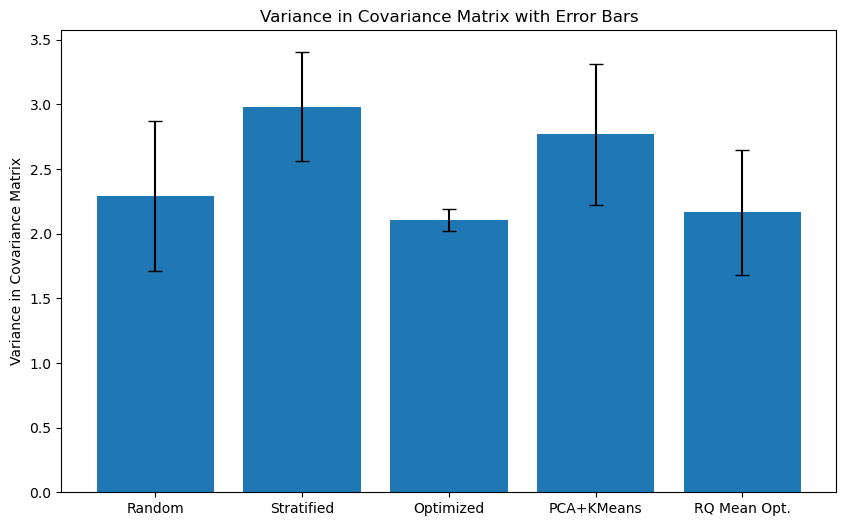

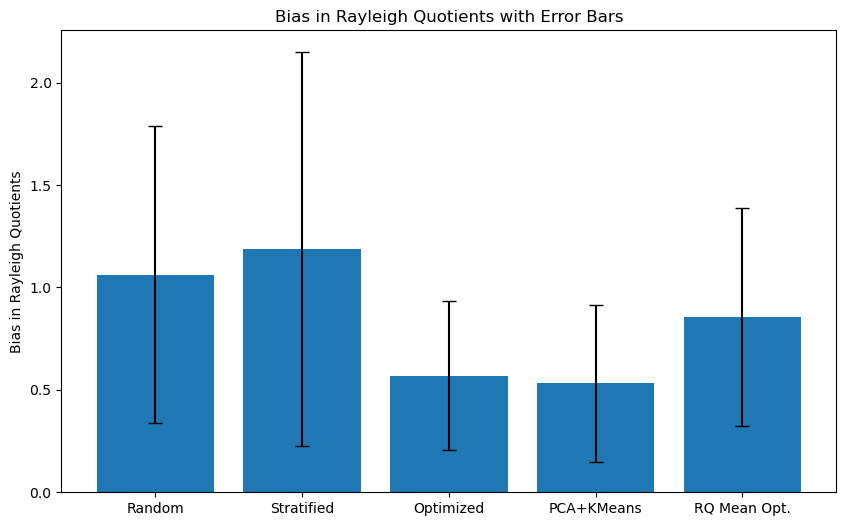

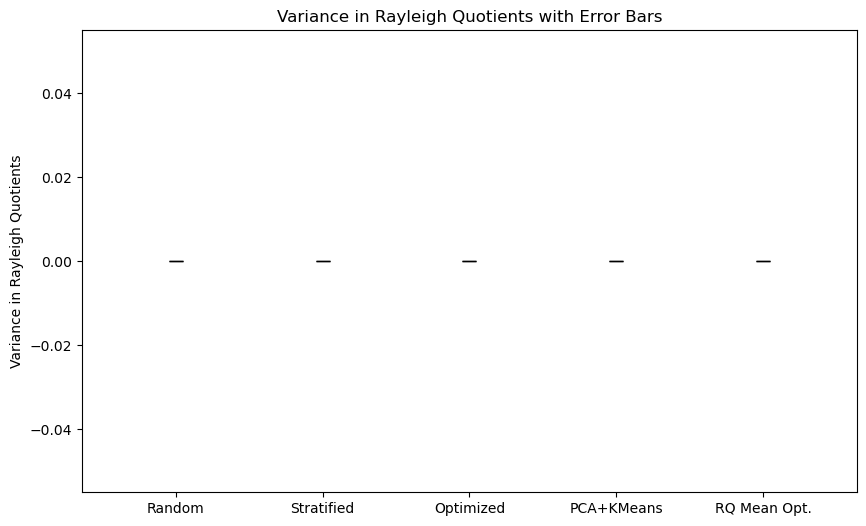

In [ ]:
# Function to compute the Rayleigh Quotient for a given weight vector and covariance matrix
def compute_rayleigh_quotient(w, cov_matrix):
    return (w.T @ cov_matrix @ w) / (w.T @ w)

# Function to print covariance matrices and RQ values for each batch
def debug_covariance_rq(cov_matrices, rq_values):
    print("Covariance Matrix Differences (Frobenius Norm):")
    for i in range(len(cov_matrices) - 1):
        diff = np.linalg.norm(cov_matrices[i] - cov_matrices[i + 1], 'fro')
        print(f"Batch {i} vs Batch {i + 1}: Frobenius Norm of Covariance Difference = {diff}")
        
    print("\nRayleigh Quotients for each batch:")
    for i, rq in enumerate(rq_values):
        print(f"Batch {i}: RQ = {rq}")

# Compute covariances, RQ, and bias/variance with multiple methods
def compute_covariances_rq_bias_with_pca_kmeans(X, batch_size, num_batches, w):
    # Full data covariance matrix and RQ
    cov_whole = compute_covariance_matrix(X)
    rq_whole = compute_rayleigh_quotient(w, cov_whole)

    # Random Sampling
    cov_matrices_random = random_sampling(X, batch_size, num_batches)
    rq_random = [compute_rayleigh_quotient(w, cov) for cov in cov_matrices_random]
    
    # Debugging covariance matrices and RQ values
    print("\nRandom Sampling Debug:")
    debug_covariance_rq(cov_matrices_random, rq_random)

    # Covariance-Based Stratified Sampling
    cluster_labels = pca_kmeans_stratification(X, num_batches)
    cov_matrices_stratified = stratified_sampling(X, cluster_labels, batch_size, num_batches)
    rq_stratified = [compute_rayleigh_quotient(w, cov) for cov in cov_matrices_stratified]
    
    # Debugging covariance matrices and RQ values
    print("\nStratified Sampling Debug:")
    debug_covariance_rq(cov_matrices_stratified, rq_stratified)

    # Optimization-Based Partitioning (Variance Minimization)
    optimized_partition = partition_covariance_minimization(X, num_batches)
    cov_matrices_optimized = [compute_covariance_matrix(X[optimized_partition == i]) for i in range(num_batches)]
    rq_optimized = [compute_rayleigh_quotient(w, cov) for cov in cov_matrices_optimized]
    
    # Debugging covariance matrices and RQ values
    print("\nOptimization-Based Partitioning Debug:")
    debug_covariance_rq(cov_matrices_optimized, rq_optimized)

    # PCA + KMeans clustering stratification
    cluster_labels_pca_kmeans = pca_kmeans_stratification(X, num_batches)
    cov_matrices_pca_kmeans = stratified_sampling(X, cluster_labels_pca_kmeans, batch_size, num_batches)
    rq_pca_kmeans = [compute_rayleigh_quotient(w, cov) for cov in cov_matrices_pca_kmeans]
    
    # Debugging covariance matrices and RQ values
    print("\nPCA + KMeans Clustering Debug:")
    debug_covariance_rq(cov_matrices_pca_kmeans, rq_pca_kmeans)

    # New Optimization Based on Mean RQ
    optimized_partition_rq_mean = partition_rq_mean_minimization(X, num_batches, w)
    cov_matrices_rq_mean_optimized = [compute_covariance_matrix(X[optimized_partition_rq_mean == i]) for i in range(num_batches)]
    rq_rq_mean_optimized = [compute_rayleigh_quotient(w, cov) for cov in cov_matrices_rq_mean_optimized]
    
    # Debugging covariance matrices and RQ values
    print("\nRQ Mean Optimization Debug:")
    debug_covariance_rq(cov_matrices_rq_mean_optimized, rq_rq_mean_optimized)

    return {
        'Random': compute_bias_variance_over_nodes(cov_matrices_random, rq_random, cov_whole, rq_whole),
        'Stratified': compute_bias_variance_over_nodes(cov_matrices_stratified, rq_stratified, cov_whole, rq_whole),
        'Optimized': compute_bias_variance_over_nodes(cov_matrices_optimized, rq_optimized, cov_whole, rq_whole),
        'PCA+KMeans': compute_bias_variance_over_nodes(cov_matrices_pca_kmeans, rq_pca_kmeans, cov_whole, rq_whole),
        'RQ Mean Opt.': compute_bias_variance_over_nodes(cov_matrices_rq_mean_optimized, rq_rq_mean_optimized, cov_whole, rq_whole)
    }

# Running the analysis
results = compute_covariances_rq_bias_with_pca_kmeans(X, batch_size, num_batches, w)
plot_bias_variance_with_errorbars(results)

In [ ]:
import torch
import numpy as np
import torch.optim as optim

# Prune nodes based on their RQ values
def prune_nodes_by_rq(net, dataloader, batch_size, prune_percentage):
    # Loop through each layer and prune based on RQ
    for layer in net.layers:
        if hasattr(layer, 'weight'):
            layer_weight = layer.weight.detach().cpu().numpy()
            rqs = []

            # Compute RQ for each node based on the current batch size
            for images, _ in dataloader:
                images = images.view(images.size(0), -1)
                for node_idx in range(layer.out_features):
                    rq_value = compute_rq(layer_weight[node_idx], images.numpy())
                    rqs.append((node_idx, rq_value))

            # Sort nodes by their RQ and prune the lowest prune_percentage%
            rqs.sort(key=lambda x: x[1])
            prune_count = int(len(rqs) * prune_percentage / 100)
            nodes_to_prune = [rq[0] for rq in rqs[:prune_count]]
            
            # Set the weights of pruned nodes to zero
            with torch.no_grad():
                for node_idx in nodes_to_prune:
                    layer.weight[node_idx, :] = 0

# Function to evaluate model performance after pruning
def evaluate_model_performance(net, test_loader, device='cpu'):
    correct = 0
    total = 0
    net.eval()
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.view(images.size(0), -1).to(device)
            labels = labels.to(device)
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

# Example Usage: Test how different batch sizes for RQ-based pruning affect performance
batch_sizes = [16, 32, 64, 128]
train_loader, test_loader = load_datasets(batch_size=batch_sizes[0])
net = MultilayerNet(input_size=28*28, hidden_sizes=[128, 64], num_classes=10)

# Assume the network is already trained with a large batch size
for batch_size in batch_sizes:
    prune_nodes_by_rq(net, train_loader, batch_size=batch_size, prune_percentage=10)
    accuracy = evaluate_model_performance(net, test_loader)
    print(f'Batch Size: {batch_size}, Accuracy after Pruning: {accuracy:.4f}')

NameError: name 'load_datasets' is not defined

In [ ]:
from sklearn.metrics import mutual_info_score

# Prune nodes based on MI between node activations and target labels
def prune_nodes_by_mi(net, dataloader, batch_size, prune_percentage, labels):
    for layer in net.layers:
        if hasattr(layer, 'weight'):
            layer_weight = layer.weight.detach().cpu().numpy()
            mi_scores = []

            # Compute MI for each node
            for images, labels in dataloader:
                images = images.view(images.size(0), -1)
                outputs = net(images)
                for node_idx in range(layer.out_features):
                    activations = outputs[:, node_idx].detach().cpu().numpy()
                    mi_value = mutual_info_score(activations, labels.numpy())
                    mi_scores.append((node_idx, mi_value))

            # Sort nodes by MI and prune the lowest prune_percentage%
            mi_scores.sort(key=lambda x: x[1])
            prune_count = int(len(mi_scores) * prune_percentage / 100)
            nodes_to_prune = [mi[0] for mi in mi_scores[:prune_count]]
            
            # Set the weights of pruned nodes to zero
            with torch.no_grad():
                for node_idx in nodes_to_prune:
                    layer.weight[node_idx, :] = 0

# Example usage with MI-based pruning
prune_nodes_by_mi(net, train_loader, batch_size=64, prune_percentage=10, labels=labels)
accuracy = evaluate_model_performance(net, test_loader)
print(f'Accuracy after MI-based Pruning: {accuracy:.4f}')

In [ ]:
import numpy as np

# Compute RQ for each node over the entire dataset
def compute_rq_for_all_data(net, dataloader):
    rqs = []
    for images, _ in dataloader:
        images = images.view(images.size(0), -1)
        for layer in net.layers:
            if hasattr(layer, 'weight'):
                for node_idx in range(layer.out_features):
                    weights = layer.weight[node_idx].detach().cpu().numpy()
                    rq_value = compute_rq(weights, images.numpy())
                    rqs.append(rq_value)
    return np.array(rqs)

# Stratified batch selection based on RQ
def stratified_batch_selection(dataloader, net, num_batches):
    rqs = compute_rq_for_all_data(net, dataloader)
    
    # Sort data by RQ values
    sorted_indices = np.argsort(rqs)
    sorted_data = [(dataloader.dataset[i], rqs[i]) for i in sorted_indices]
    
    # Split the sorted data into batches
    batches = np.array_split(sorted_data, num_batches)
    
    stratified_loader = []
    for batch in batches:
        images = torch.stack([item[0][0] for item in batch])
        labels = torch.tensor([item[0][1] for item in batch])
        stratified_loader.append((images, labels))
    
    return stratified_loader

# Evaluate performance with stratified batches
def evaluate_with_stratified_batches(net, stratified_loader, device='cpu'):
    correct = 0
    total = 0
    net.eval()
    with torch.no_grad():
        for images, labels in stratified_loader:
            images = images.view(images.size(0), -1).to(device)
            labels = labels.to(device)
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

# Example usage with stratified batch selection
stratified_loader = stratified_batch_selection(train_loader, net, num_batches=10)
accuracy_stratified = evaluate_with_stratified_batches(net, stratified_loader)
print(f'Accuracy with Stratified Batches: {accuracy_stratified:.4f}')